## 다중 분류 신경망의 구조
- 이전까지는 이진 분류였음.
- <img src="img/zn.png" width="400"/>  

## 소프트맥스 함수
- 출력의 합을 1로 만든다(확률!)
- $y_1 = 0.9$, $y_2=0.8$, $y_3=0.7$,  
$y_1 = 0.5$, $y_2=0.2$, $y_3=0.1$ 로 결과가 나온 두 모델의 정확도는 비교가 어려움.

- $p_i = \frac {e^{z_i}} {\sum_{j=1}^n e^{z_j}}$ $p_i$는 $i$번째 클래스 가 정답일 확률, $z_i$는 $i$번째 클래스의 출력값
- $\mathtt{softmax}(z) = \mathtt{softmax}(\begin{bmatrix} z_1 & z_2 & \cdots & z_k \end{bmatrix}) = \begin{bmatrix} \frac {e^{z_1}} {\sum_{j=1}^k e^{z_j}} & \frac {e^{z_2}} {\sum_{j=1}^k e^{z_j}} & \cdots & \frac {e^{z_k}} {\sum_{j=1}^k e^{z_j}} \end{bmatrix} = \begin{bmatrix} p_1 & p_2 & \cdots & p_k \end{bmatrix}$



## 크로스 엔트로피 손실 함수
- 크로스 엔트로피 손실 함수의 이진 버전이 로지스틱 함수이다.
- $L = -\sum_{i=1}^c y_i \ln a_i = -(y_1 \ln a_1 + y_2 \ln a_2 + \cdots + y_c \ln a_c)$
- 원-핫 벡터(한 원소 외의 다른 원소는 모두 0인 벡터)를 쓰면, $y_i = [0, \cdots, 0, \underbrace{1}_{i 번째 원소}, 0, \cdots, 0]$ 이므로 $L = -\ln a_i$ 이다.

### 크로스 엔트로피 손실 함수 미분
- <img src="img/zo.png" width="300"/>  

$$\begin{align*}
\frac{\partial L}{\partial a_i} &= -\frac{\partial}{\partial a_i}(y_1 \ln a_1 + \cdots + y_i \ln a_i + \cdots + y_c \ln a_c) = -\frac{y_i}{a_i}
\\ \frac{\partial a_i}{\partial z_i} &= \frac{\partial}{\partial z_i} \left(\frac{e^{z_i}}{S}\right) = \frac{e^{z_i} S - e^{z_i} e^{z_i}}{S^2} = \frac {e^{z_i}}{S} - \left(\frac{e^{z_i}}{S}\right)^2 = a_i - a_i^2 = a_i(1 - a_i) \quad \left(S = \sum_{k=1}^c e^{z_k},\quad\frac {\partial S}{\partial z_i} = e^{z_i}\right)
\\ \quad \frac{\partial a_j}{\partial z_i} &= \frac{\partial a_j}{\partial z_i} = \frac{\partial}{\partial z_i} \left(\frac{e^{z_j}}{S}\right) = \frac{0 \cdot S - e^{z_j} e^{z_i}}{S^2} = -\frac{e^{z_j} e^{z_i}}{S^2} = -a_j a_i \quad (i \neq j)
\\ \therefore \quad \frac{\partial L}{\partial z_i} &= \sum_{j=1}^c \frac{\partial L}{\partial a_j} \frac{\partial a_j}{\partial z_i}
\\ &= \sum_{j=1}^c \left(-\frac{y_j}{a_j}\right) \frac{\partial a_j}{\partial z_i}
\\ &= \left(-\frac{y_1}{a_1}\right) \frac{\partial a_1}{\partial z_i} + \cdots + \left(-\frac{y_i}{a_i}\right) \frac{\partial a_i}{\partial z_i} + \cdots + \left(-\frac{y_c}{a_c}\right) \frac{\partial a_c}{\partial z_i}
\\ &=\left(-\frac{y_1}{a_1}\right) (-a_1 a_i) + \cdots + \left(-\frac{y_i}{a_i}\right) (a_i(1 - a_i)) + \cdots + \left(-\frac{y_c}{a_c}\right) (-a_c a_i)
\\ &=y_1 a_i + \cdots + [-y_i(1 - a_i)] + \cdots + y_c a_i
\\ &= a_i\sum_{j=1}^c y_j - y_i
\\ &= a_i - y_i \quad(\because \sum_{j=1}^c y_j = 1)
\\ &= -(y_i - a_i)
\\ \therefore \quad \frac{\partial L}{\partial z} &= -(y - a)
\end{align*}$$

In [45]:
import numpy as np

class MultiClassNetwork:

    def __init__(self, units=10, batch_size=32, learning_rate=0.1, l1=0, l2=0):
        
        self.units = units # 은닉층 뉴런 갯수
        self.batch_size = batch_size # 배치 크기
        self.w1 = None # 은닉층 가중치
        self.b1 = None # 은닉층 절편
        self.w2 = None # 출력층 가중치
        self.b2 = None # 출력층 절편
        self.a1 = None # 은닉층 활성화 출력
        self.losses = [] # 훈련 손실
        self.val_losses = [] # 검증 손실
        self.lr = learning_rate # 학습률
        self.l1 = l1 # L1 규제
        self.l2 = l2 # L2 규제

    def forpass(self, x):
        z1 = np.dot(x, self.w1) + self.b1 # 첫번째 층의 선형 계산
        self.a1 = self.sigmoid(z1) # 활성화 함수(시그모이드) 적용
        z2 = np.dot(self.a1, self.w2) + self.b2 # 두번째 층 선형 계산
        return z2
    
    def backprop(self, x, err):

        m = len(x) # 샘플 개수
        # 출력층 가중치/절편에 대한 그래디언트 계산
        w2_grad = np.dot(self.a1.T, err) / m
        b2_grad = np.sum(err) / m

        # 시그모이드 함수까지 그래디언트 계산
        err_to_hidden = np.dot(err, self.w2.T,) * self.a1 * (1 - self.a1)

        # 은닉층 가중치/절편에 대한 그래디언트 계산
        w1_grad = np.dot(x.T, err_to_hidden) / m
        b1_grad = np.sum(err_to_hidden, axis=0) / m
        return w1_grad, b1_grad, w2_grad, b2_grad
    
    def sigmoid(self, z):
        z = np.clip(z, -100, None)
        a = 1 / (1 + np.exp(-z))
        return a
    
    # 소프트 맥스 함수!!
    def softmax(self, z):
        z = np.clip(z, -100, None)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1).reshape(-1, 1)

    def init_weights(self, n_features, n_classes):
        np.random.seed(42)
        self.w1 = np.random.normal(0, 1, (n_features, self.units))
        self.b1 = np.zeros(self.units)
        self.w2 = np.random.normal(0, 1, (self.units, n_classes))
        self.b2 = np.zeros(n_classes)

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        np.random.seed(42)

        self.init_weights(x.shape[1], y.shape[1])
        for i in range(epochs):

            loss = 0
            print('.', end='')
            for x_batch, y_batch in self.gen_batch(x, y):
                a = self.training(x_batch, y_batch)
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += np.sum(-y_batch*np.log(a)) # 크로스 엔트로피 손실 함수

            self.losses.append((loss + self.reg_loss()) / len(x))
            self.update_val_loss(x_val, y_val)
 
    def gen_batch(self, x, y):
        length = len(x)
        bins = length // self.batch_size
        if length % self.batch_size:
            bins += 1 # 나누어 떨어지지 않을때(length%self.batch_size != 0)
        indexes = np.random.permutation(np.arange(len(x)))
        x = x[indexes]
        y = y[indexes]
        for i in range(bins):
            start = self.batch_size * i
            end = self.batch_size * (i + 1)
            yield x[start:end], y[start:end]

    def training(self, x, y):
        m = len(x)
        z = self.forpass(x) # 정방향 계산 수행
        a = self.softmax(z) # 소프트맥스 함수 적용
        err = -(y - a)
        # 오차를 역전파하여 그래디언트 계산
        w1_grad, b1_grad, w2_grad, b2_grad = self.backprop(x, err)

        # 그래디언트에 패널티 항의 미분 값 더함
        w1_grad += (self.l1 * np.sign(self.w1) + self.l2 * self.w1) / m
        w2_grad += ( self.l1 * np.sign(self.w2) + self.l2 * self.w2) / m
        
        # 은닉층의 가중치와 절편 업데이트
        self.w1 -= self.lr * w1_grad
        self.b1 -= self.lr * b1_grad

        # 출력층 가중치와 절편 업데이트
        self.w2 -= self.lr * w2_grad
        self.b2 -= self.lr * b2_grad
        return a
    
    def predict(self, x):
        z = self.forpass(x)
        return np.argmax(z, axis=1)
    
    def score(self, x, y):
        return np.mean(self.predict(x) == np.argmax(y, axis=1))

    def reg_loss(self):
        return self.l1 * (np.sum(np.abs(self.w1)) + np.sum(np.abs(self.w2))) + self.l2 / 2 * (np.sum(self.w1**2) + np.sum(self.w2**2)) # L1, L2 계산

    def update_val_loss(self, x_val, y_val):

        z = self.forpass(x_val)
        a = self.softmax(z)
        a = np.clip(a, 1e-10, 1-1e-10)

        val_loss = np.sum(-y_val*np.log(a))
        self.val_losses.append((val_loss + self.reg_loss()) / len(y_val))

샘플의 개수: 150
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
품종 종류: 
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


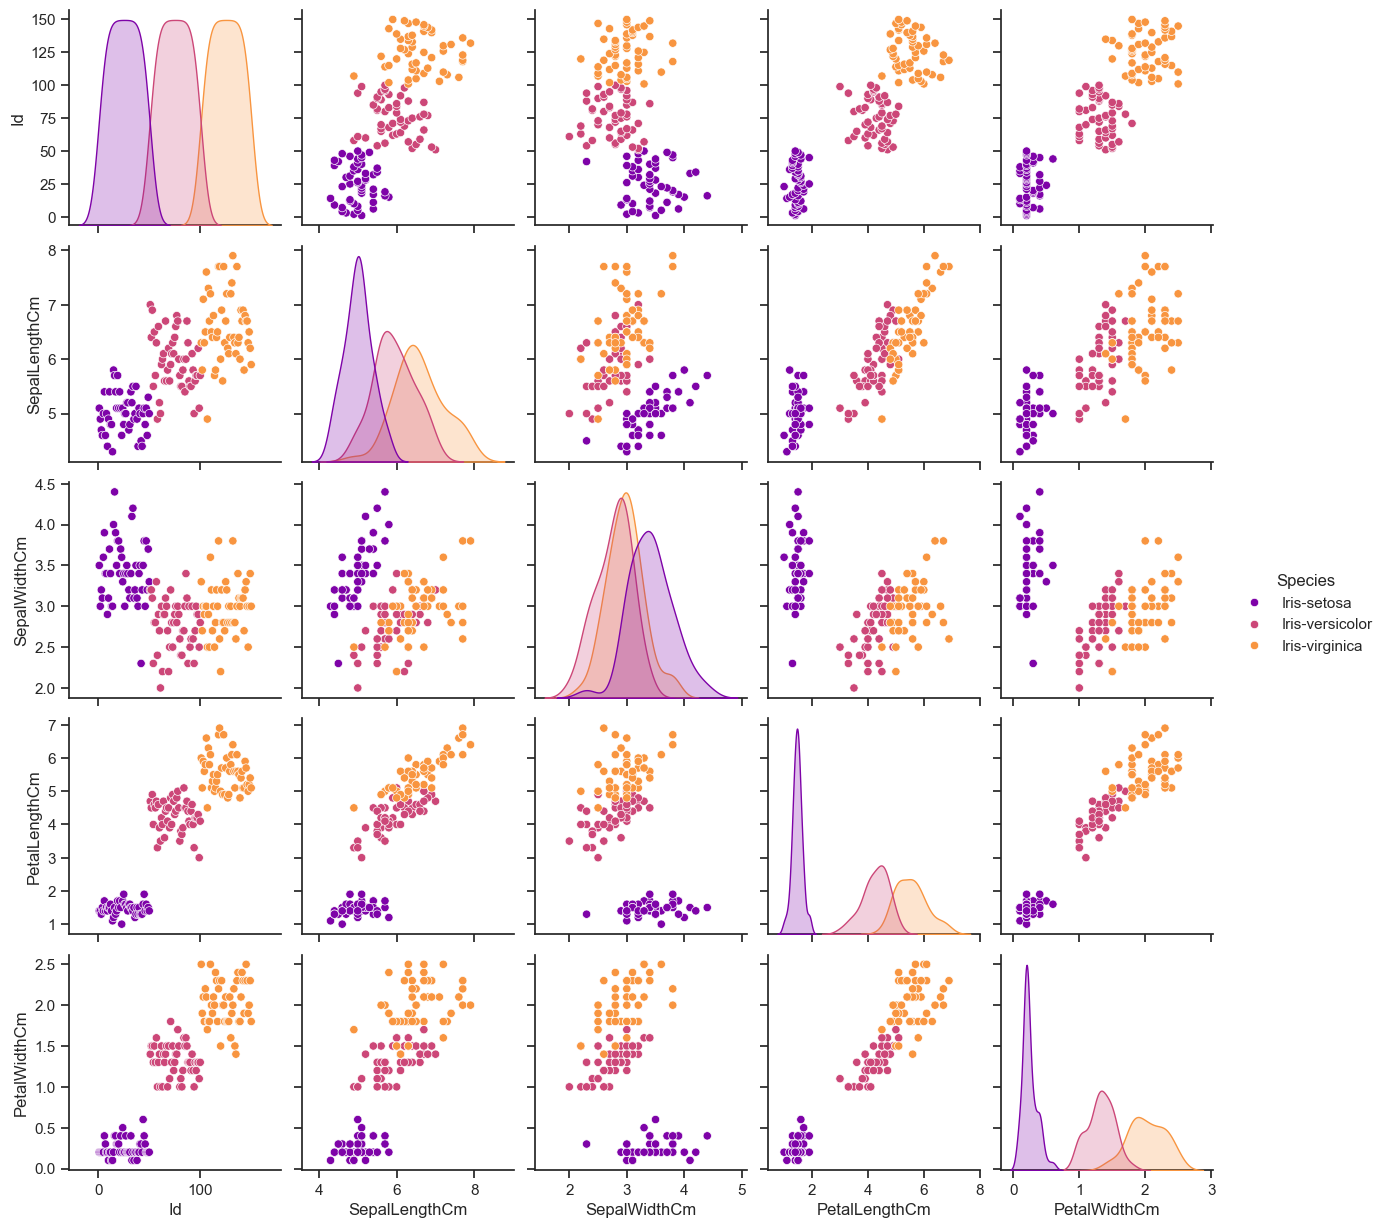

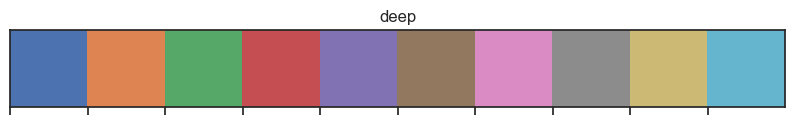

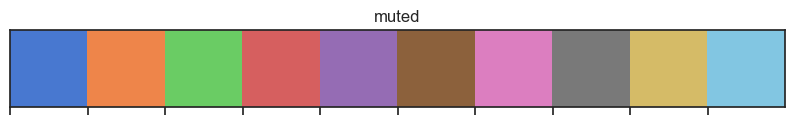

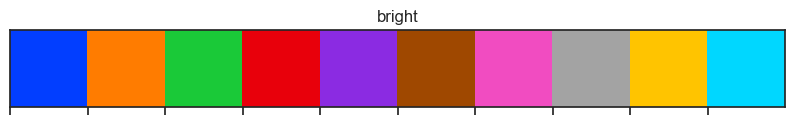

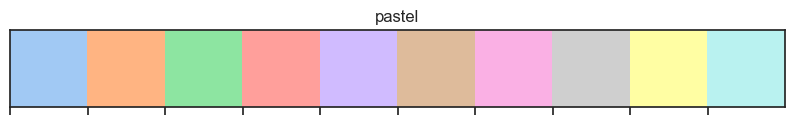

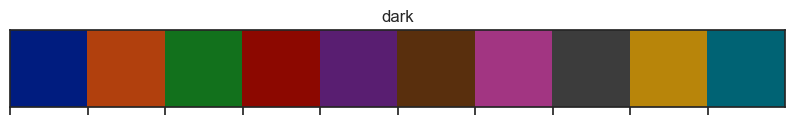

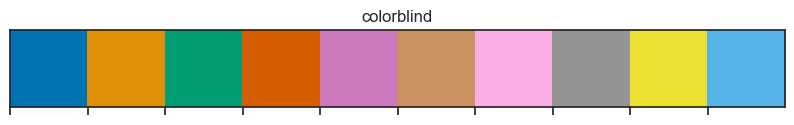

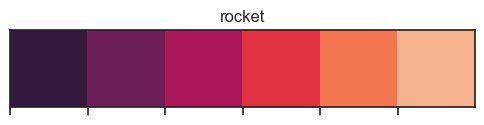

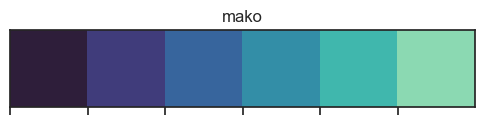

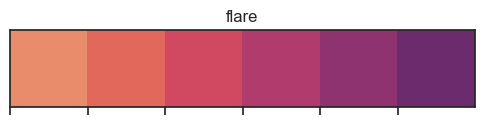

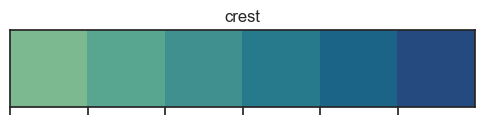

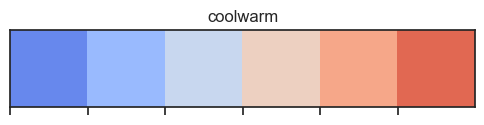

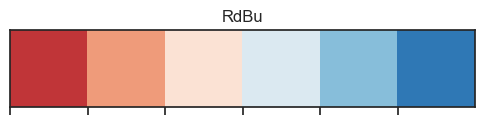

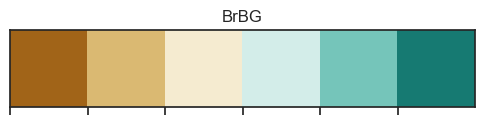

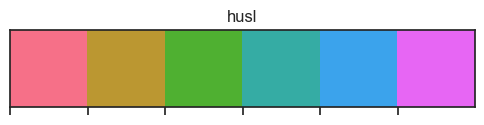

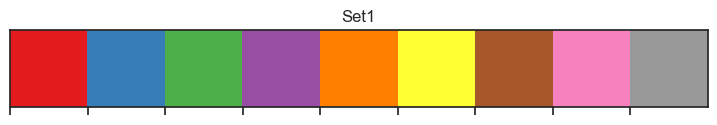

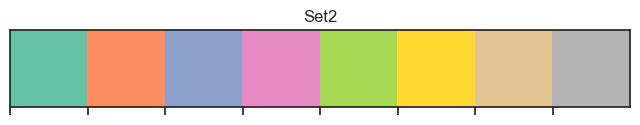

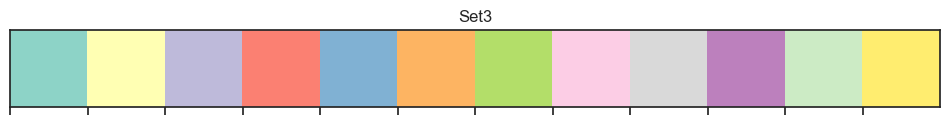

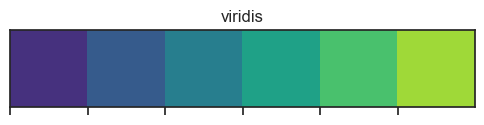

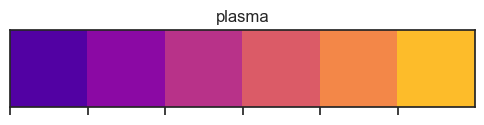

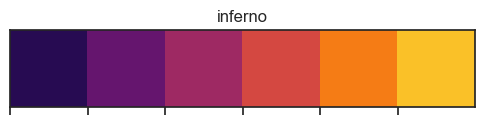

In [46]:
import pandas as pd
import seaborn as sns
import urllib.request
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/06.%20Machine%20Learning/dataset/Iris.csv", filename="data/saved/Iris.csv")

data = pd.read_csv('data/saved/Iris.csv', encoding='latin1')
print('샘플의 개수:', len(data))
print(data.head())

print("품종 종류: ", data["Species"].unique(), sep="\n")

sns.set(style="ticks", color_codes=True)
# 스타일 설정.
# style="ticks": grid 없이 축에 눈금만 표시
# color_codes=True: matplotlib에서 쓰는 기본 색상 코드('r', 'g', 'b', ...) 를 Seaborn 색상 팔레트로 해석해서 적용
g = sns.pairplot(data, hue="Species", palette='plasma')
# 데이터의 모든 수치형 컬럼을 짝지어 그래프를 그림
# hue="Special": Special 값에 따라 색상을 다르게 표시
# palette='husl' 색상 조합/ deep, muted, bright, pastel, dark, colorblind, rocket, mako, flare, crest, coolwarm, RdBu, BrBG, husl, Set1, Set2, Set3, viridis, plasma, inferno


for c in 'deep, muted, bright, pastel, dark, colorblind, rocket, mako, flare, crest, coolwarm, RdBu, BrBG, husl, Set1, Set2, Set3, viridis, plasma, inferno'.split(', '):
    cp = sns.color_palette(c)
    sns.palplot(cp)
    plt.title(c)
    plt.show()

C:\Users\0627j\AppData\Local\Temp\ipykernel_10888\1479340962.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=data["Species"], y=data["SepalWidthCm"], ci=None, palette='husl')
C:\Users\0627j\AppData\Local\Temp\ipykernel_10888\1479340962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data["Species"], y=data["SepalWidthCm"], ci=None, palette='husl')


<Axes: xlabel='Species', ylabel='SepalWidthCm'>

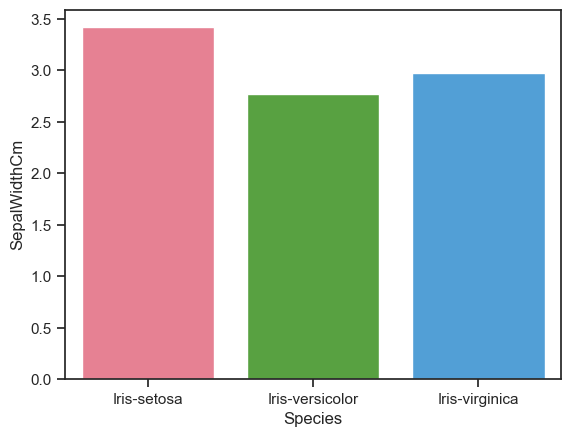

In [47]:
# 각 종과 특성에 대한 연관 관계
sns.barplot(x=data["Species"], y=data["SepalWidthCm"], ci=None, palette='husl')

<Axes: xlabel='Species'>

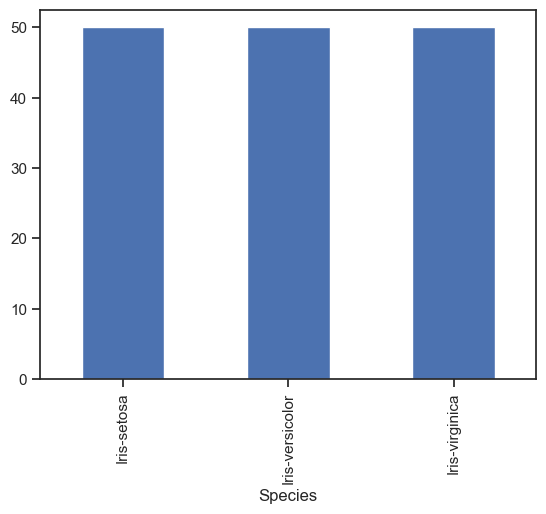

In [48]:
data['Species'].value_counts().plot(kind='bar')

C:\Users\0627j\AppData\Local\Temp\ipykernel_10888\1742170708.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Species"] = data["Species"].replace(["Iris-virginica", 'Iris-setosa', 'Iris-versicolor'], [0, 1, 2])


<Axes: xlabel='Species'>

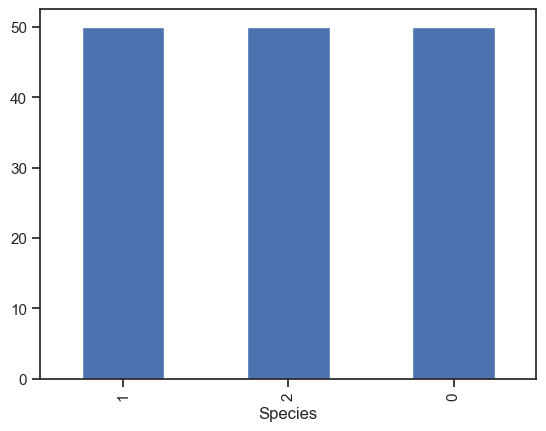

In [49]:
# Iris-virginica, Iris-setosa, Iris-versicolor --> 0, 1, 2

data["Species"] = data["Species"].replace(["Iris-virginica", 'Iris-setosa', 'Iris-versicolor'], [0, 1, 2])
data['Species'].value_counts().plot(kind='bar')

In [50]:
# X 데이터. 특성은 총 4개
data_X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values

# Y 데이터. 예측 대상
data_y = data["Species"].values

print(data_X[:5])
print(data_y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[1 1 1 1 1]


In [56]:
# 훈련 데이터와 테스트 데이터를 8:2로 나눔
(X_train, X_test, y_train, y_test) = train_test_split(data_X, data_y, train_size=0.8, random_state=1)

print(y_train[:5])
print(y_test[:5])

# 원-핫 인코딩, 인자는 0부터 시작하는 정수여야함
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train[:5])
print(y_test[:5])

[2 0 2 0 0]
[1 2 2 1 0]
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]]
[[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


Epoch 1/200
120/120 [==============================] - 0s 1ms/step - loss: 5.8505 - accuracy: 0.3667 - val_loss: 6.8446 - val_accuracy: 0.2000
Epoch 2/200
120/120 [==============================] - 0s 878us/step - loss: 4.5558 - accuracy: 0.3667 - val_loss: 5.1345 - val_accuracy: 0.2000
Epoch 3/200
120/120 [==============================] - 0s 1ms/step - loss: 3.2677 - accuracy: 0.3667 - val_loss: 3.4650 - val_accuracy: 0.2000
Epoch 4/200
120/120 [==============================] - 0s 1ms/step - loss: 2.1289 - accuracy: 0.3667 - val_loss: 2.1214 - val_accuracy: 0.2000
Epoch 5/200
120/120 [==============================] - 0s 919us/step - loss: 1.4439 - accuracy: 0.3667 - val_loss: 1.4812 - val_accuracy: 0.2000
Epoch 6/200
120/120 [==============================] - 0s 977us/step - loss: 1.1545 - accuracy: 0.4083 - val_loss: 1.2057 - val_accuracy: 0.2000
Epoch 7/200
120/120 [==============================] - 0s 936us/step - loss: 1.0107 - accuracy: 0.4000 - val_loss: 1.0722 - val_accuracy

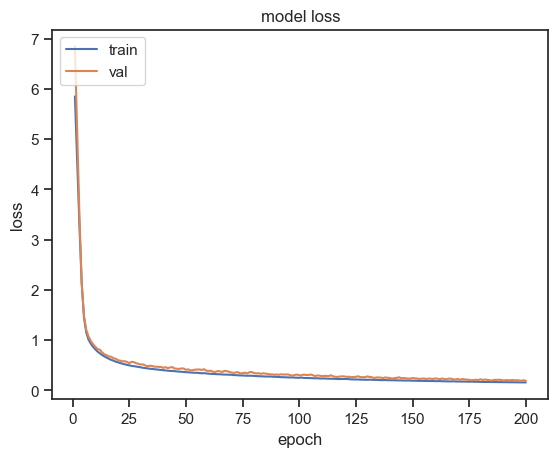

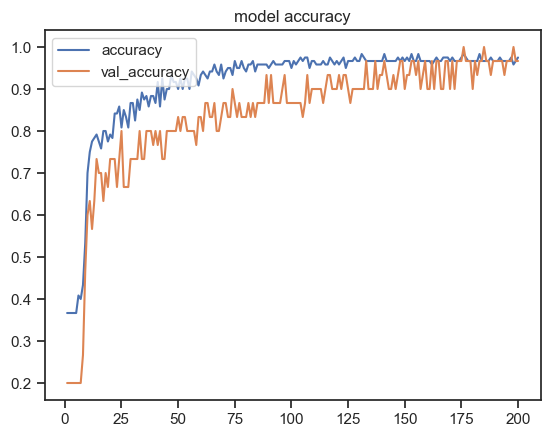

1/1 [==============================] - 0s 63ms/step - loss: 0.1913 - accuracy: 0.9667

 테스트 정확도: 0.9667


In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
# 입력 차원 4(특성), 출력 차원 3(3개의 꽃 종류)
model.add(Dense(3, input_dim=4, activation='softmax'))
# 이진 분류에선 binary_crossenstropy, 다중 클래스 분류에서는 categorical_crossentropy
# 경사 하강법의 일종인 아담(adam) 사용
# 확인하고자 하는 수치는 정확도(전체 중 맞힌 비율, 그 외에도 정밀도(Precision, 모델이 정답이라 한 것 중 정답 비율), 재현율(Recall, 진짜 정답 중 모델이 맞힌 비율))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test))
epochs = range(1, len(history.history['accuracy']) + 1)

plt.plot(epochs, history.history['loss'])
plt.plot(epochs, history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, history.history['accuracy'])
plt.plot(epochs, history.history['val_accuracy'])
plt.title('model accuracy')
plt.legend(['accuracy', 'val_accuracy'], loc='upper left')
plt.show()

print(f"\n 테스트 정확도: {model.evaluate(X_test, y_test)[1]:.4f}")

(60000, 28, 28) (60000,)


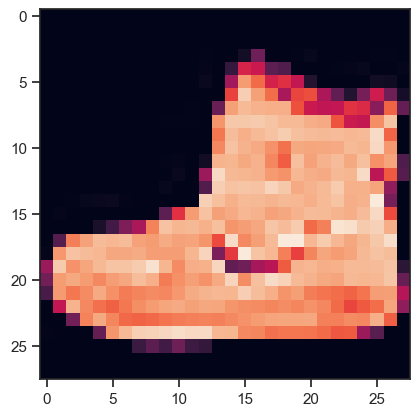

[9 0 0 3 0 2 7 2 5 5]
[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
[4800 4800 4800 4800 4800 4800 4800 4800 4800 4800]
[1200 1200 1200 1200 1200 1200 1200 1200 1200 1200]
(48000, 28, 28) (12000, 28, 28)
(48000, 784) (12000, 784)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]] [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
6 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
........................................

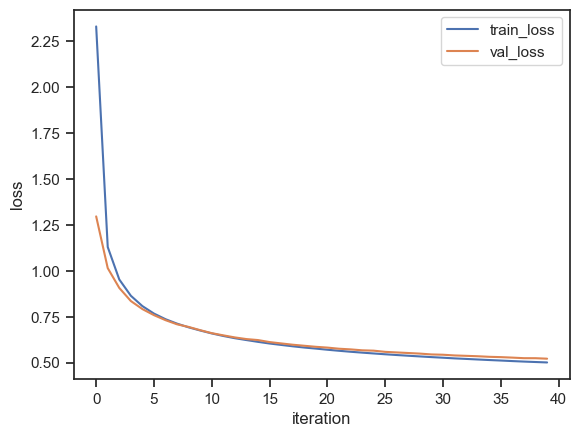

0.8150833333333334


In [53]:
# 의류 데이터: 6만개의 28x28 흑백 이미지로 구성되어 있음

import tensorflow as tf

(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train_all.shape, y_train_all.shape)

plt.imshow(x_train_all[0])
plt.show()

print(y_train_all[:10])

print(np.bincount(y_train_all))

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)

print(np.bincount(y_train))
print(np.bincount(y_val))

x_train = x_train / 255
x_val = x_val / 255

print(x_train.shape, x_val.shape)

# MultiClassNetwork는 1차원 배열을 입력으로 기대하므로, 28x28의 2차원인 패션 MNIST 데이터는 사용불가. 784의 1차원으로 변환 필요
x_train = x_train.reshape(-1, 784)
x_val = x_val.reshape(-1, 784)

print(x_train.shape, x_val.shape)

# 10개의 뉴런으로 구성된 신경망을 위해 타깃 데이터는 다시 원-핫 인코딩으로 변환
y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

print(y_train_encoded, y_val_encoded)
print(y_train[0], y_train_encoded[0])

fc = MultiClassNetwork(units=100, batch_size=256)
fc.fit(x_train, y_train_encoded, x_val=x_val, y_val=y_val_encoded, epochs=40)

plt.plot(fc.losses)
plt.plot(fc.val_losses)
plt.ylabel('loss')
plt.xlabel('iteration')
plt.legend(['train_loss', 'val_loss'])

plt.show()

print(fc.score(x_val, y_val_encoded))
 